In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

In [4]:
df=pd.read_csv(r"C:\Users\User\Desktop\Data Analysis\Netflix Data Analysis\Dataset.csv")
df

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [8]:
df.describe()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s6621,Movie,The Lost Okoroshi,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


In [12]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

In [14]:
df.isnull().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

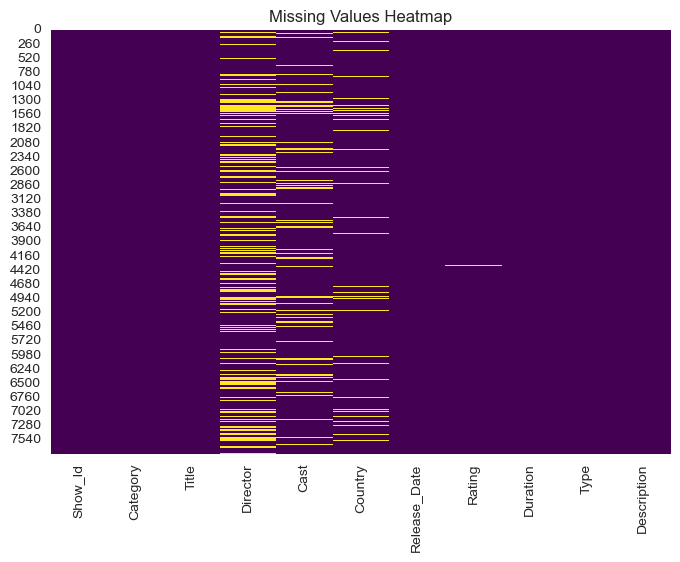

In [20]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [21]:
df['Director'].fillna('Unknown',inplace=True)
df['Cast'].fillna('Unknown',inplace=True)
df['Country'].fillna('Unknown',inplace=True)

In [22]:
df.isnull().sum()

Show_Id          0
Category         0
Title            0
Director         0
Cast             0
Country          0
Release_Date    10
Rating           7
Duration         0
Type             0
Description      0
dtype: int64

In [24]:
df.dropna(subset=['Release_Date','Rating'],inplace=True)

In [25]:
df.isnull().sum()

Show_Id         0
Category        0
Title           0
Director        0
Cast            0
Country         0
Release_Date    0
Rating          0
Duration        0
Type            0
Description     0
dtype: int64

In [27]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

In [28]:
df['Year']=df['Release_Date'].dt.year

In [30]:
df['Category'].value_counts()

Movie      5374
TV Show    2398
Name: Category, dtype: int64

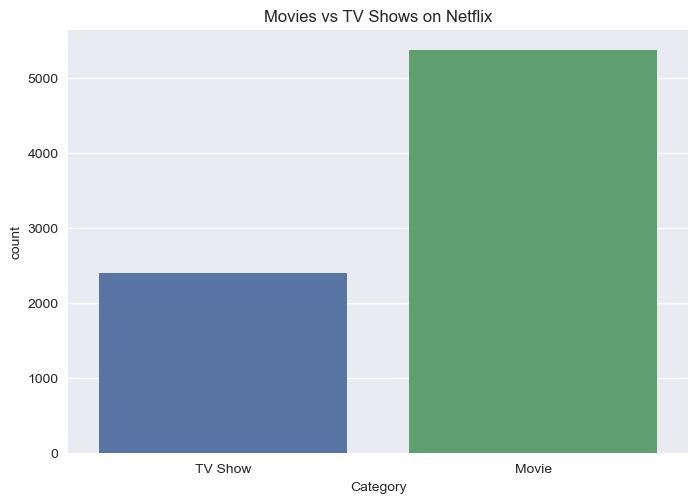

In [31]:
sns.countplot(data=df,x='Category')
plt.title("Movies vs TV Shows on Netflix")
plt.show()

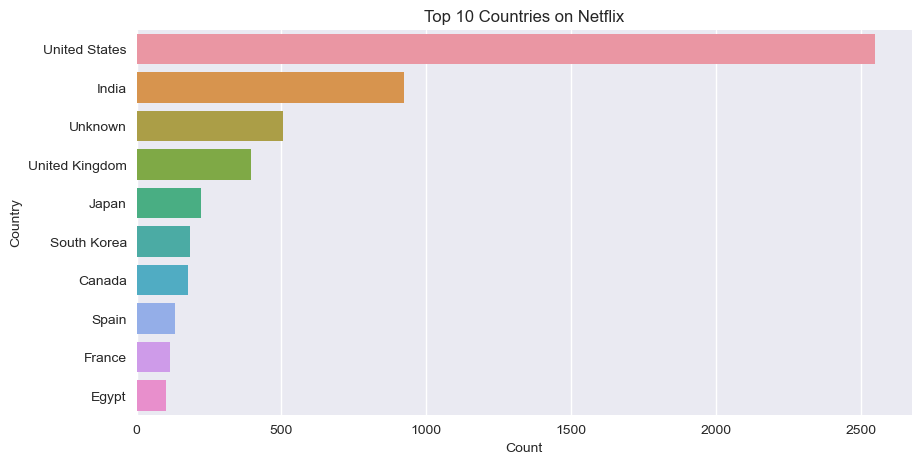

In [35]:
top_countries=df['Country'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values,y=top_countries.index)
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

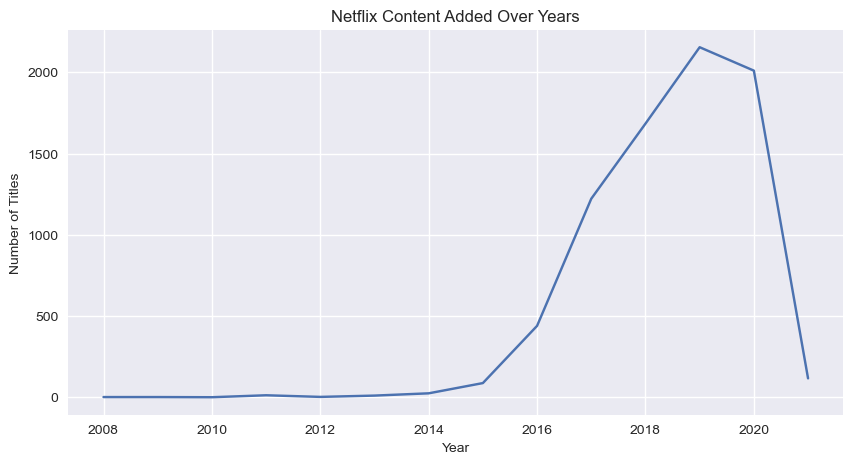

In [36]:
yearly_content = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly_content.plot(kind='line')
plt.title("Netflix Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

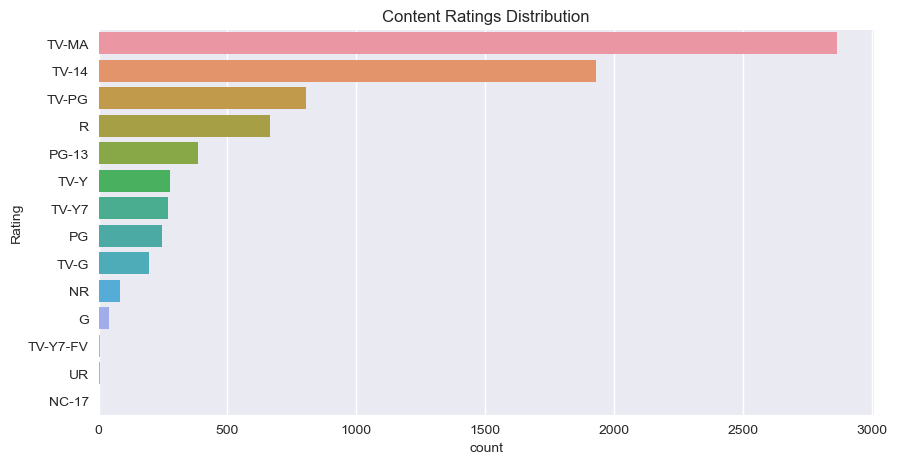

In [37]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Rating', order=df['Rating'].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

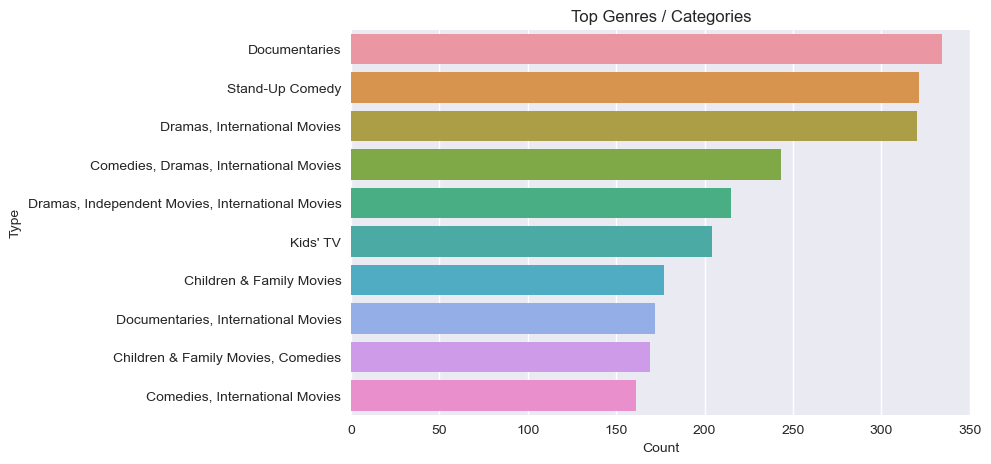

In [39]:
top_types = df['Type'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_types.values, y=top_types.index)
plt.title("Top Genres / Categories")
plt.xlabel("Count")
plt.ylabel("Type")
plt.show()

In [41]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
     ------------------------------------- 306.2/306.2 kB 19.7 MB/s eta 0:00:00


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


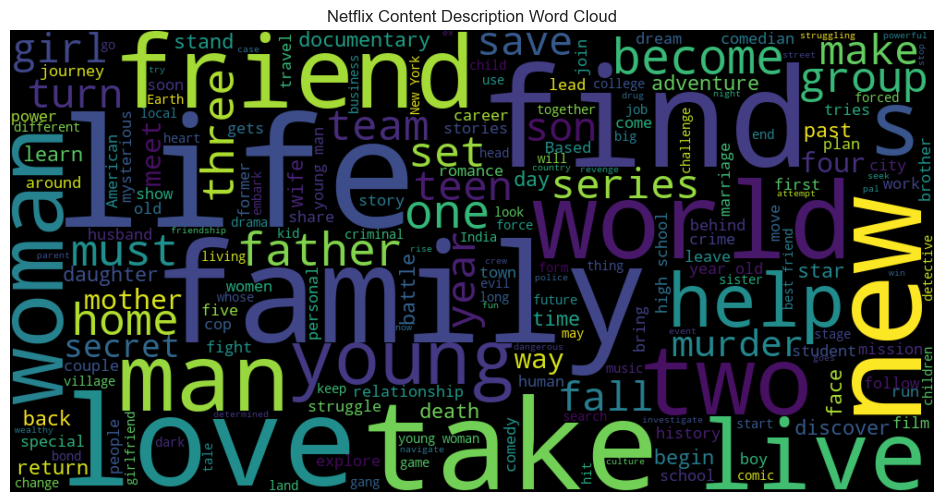

In [42]:
from wordcloud import WordCloud

text = " ".join(df['Description'].dropna())

wordcloud = WordCloud(width=1000, height=500, background_color='black').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Netflix Content Description Word Cloud")
plt.show()

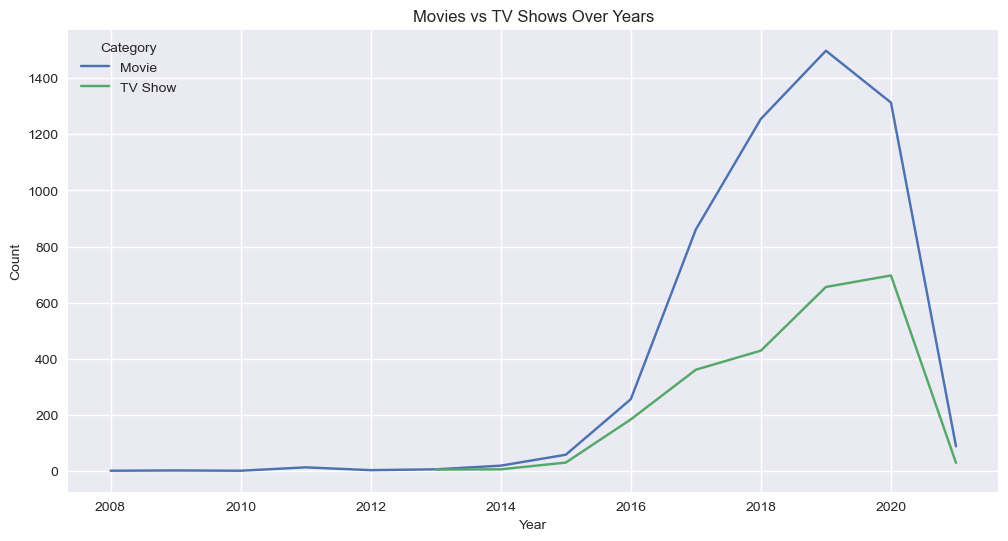

In [43]:
trend = df.groupby(['Year', 'Category']).size().unstack()

trend.plot(figsize=(12,6))
plt.title("Movies vs TV Shows Over Years")
plt.ylabel("Count")
plt.show()

In [45]:
print("INSIGHTS FROM NETFLIX DATASET")
print("--------------------------------")

print("1. Total Movies vs TV Shows:")
print(df['Category'].value_counts())

print("\n2. Top Countries:")
print(df['Country'].value_counts().head(5))

print("\n3. Most Common Rating:")
print(df['Rating'].mode()[0])

print("\n4. Year with most content:")
print(df['Year'].value_counts().idxmax())

INSIGHTS FROM NETFLIX DATASET
--------------------------------
1. Total Movies vs TV Shows:
Movie      5374
TV Show    2398
Name: Category, dtype: int64

2. Top Countries:
United States     2547
India              923
Unknown            505
United Kingdom     396
Japan              224
Name: Country, dtype: int64

3. Most Common Rating:
TV-MA

4. Year with most content:
2019
